import các thư viện cần thiết

In [23]:
from pathlib import Path
import hashlib
import platform
import subprocess

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from IPython.display import display

In [24]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (
            candidate / "data" / "data.csv"
        ).exists():
            return candidate
    raise FileNotFoundError(
        "Không tìm thấy repo root chứa pyproject.toml và data/data.csv"
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
DATA_PATH = REPO_ROOT / "data" / "data.csv"
REPORT_DIR = REPO_ROOT / "reports" / "eda"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_COLUMNS = [
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "nameDest",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
]
STRING_COLUMNS = ["type", "nameOrig", "nameDest"]
VALUE_COLUMNS = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]
NUMERIC_COLUMNS = ["step", *VALUE_COLUMNS]
VALID_TYPES = {"CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"}
VALID_BINARY = {0, 1}

CHUNK_SIZE = 250_000
NATURAL_SAMPLE_SIZE = 200_000
DIAGNOSTIC_NONFRAUD_PER_STRATUM = 300
STEP_BUCKET_WIDTH = 24
RANDOM_STATE = 42

BLUE = "#35618D"
ORANGE = "#D98032"
GOLD = "#C69A2D"
INK = "#263238"
LIGHT_BLUE = "#B9CDE1"
LIGHT_ORANGE = "#F2C49B"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5.5),
        "figure.dpi": 110,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelcolor": INK,
        "axes.edgecolor": "#AAB2B8",
        "text.color": INK,
        "xtick.color": INK,
        "ytick.color": INK,
        "grid.color": "#E4E8EB",
        "grid.linewidth": 0.8,
    }
)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

Kiểm tra cột có đầy đủ k

In [25]:
observed_columns = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
assert observed_columns == EXPECTED_COLUMNS, {
    "observed": observed_columns,
    "expected": EXPECTED_COLUMNS,
}

Metadata cho lần chạy này

In [26]:
with DATA_PATH.open("rb") as file:
    csv_sha256 = hashlib.file_digest(file, "sha256").hexdigest()

git_commit = subprocess.run(
    ["git", "rev-parse", "--short", "HEAD"],
    cwd=REPO_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()

input_metadata = pd.DataFrame(
    [
        ("data_path", str(DATA_PATH)),
        ("file_size_mb", DATA_PATH.stat().st_size / 1024**2),
        ("csv_sha256", csv_sha256),
        ("git_commit", git_commit),
        ("python_version", platform.python_version()),
        ("pandas_version", pd.__version__),
        ("matplotlib_version", matplotlib.__version__),
        ("chunk_size", CHUNK_SIZE),
        ("natural_sample_size", NATURAL_SAMPLE_SIZE),
        ("diagnostic_nonfraud_per_stratum", DIAGNOSTIC_NONFRAUD_PER_STRATUM),
        ("random_state", RANDOM_STATE),
    ],
    columns=["parameter", "value"],
)
display(input_metadata)

,parameter,value
0,data_path,/home/phongthanh/ML_Fraud_Banking/data/data.csv
1,file_size_mb,470.671447
2,csv_sha256,16910f90577b0d981bf8ff289714510bb89bc71bff7d3f...
3,git_commit,2fccf2b
4,python_version,3.12.3
5,pandas_version,3.0.5
6,matplotlib_version,3.11.1
7,chunk_size,250000
8,natural_sample_size,200000
9,diagnostic_nonfraud_per_stratum,300


In [27]:
def keep_lowest_priority(
    current: pd.DataFrame,
    candidates: pd.DataFrame,
    limit: int,
    priority_column: str,
) -> pd.DataFrame:
    if current.empty:
        combined = candidates
    elif candidates.empty:
        combined = current
    else:
        combined = pd.concat([current, candidates], ignore_index=True)

    if len(combined) <= limit:
        return combined
    return combined.nsmallest(
        limit, priority_column
    ).copy()  # Copy dùng để df mới này k còn phụ thuộc vào df cũ


def combine_group_summaries(parts: list[pd.DataFrame], index_name=str) -> pd.DataFrame:
    combined = pd.concat(parts)
    result = combined.groupby(level=0, dropna=False).sum(numeric_only=True)
    result.index.name = index_name
    return result

In [28]:
null_counts = pd.Series(0, index=EXPECTED_COLUMNS, dtype="int64")
empty_counts = pd.Series(0, index=STRING_COLUMNS, dtype="int64")
zero_counts = pd.Series(0, index=NUMERIC_COLUMNS, dtype="int64")
negative_counts = pd.Series(0, index=NUMERIC_COLUMNS, dtype="int64")
numeric_min = {column: np.inf for column in NUMERIC_COLUMNS}
numeric_max = {column: -np.inf for column in NUMERIC_COLUMNS}

invalid_type_count = 0
invalid_fraud_count = 0
invalid_flag_count = 0

type_parts: list[pd.DataFrame] = []
step_day_parts: list[pd.DataFrame] = []
step_parts: list[pd.DataFrame] = []
natural_reservoir = pd.DataFrame()
fraud_parts: list[pd.DataFrame] = []
nonfraud_reservoirs: dict[tuple[str, int], pd.DataFrame] = {}

natural_rng = np.random.default_rng(RANDOM_STATE)
diagnostic_rng = np.random.default_rng(RANDOM_STATE + 1)
total_rows = 0

for chunk_number, chunk in enumerate(
    pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE),
    start=1,
):
    chunk_rows = len(chunk)
    total_rows += chunk_rows

    null_counts += chunk[EXPECTED_COLUMNS].isna().sum()
    stripped_string = (
        chunk[STRING_COLUMNS].astype("string").apply(lambda column: column.str.strip())
    )
    empty_counts += stripped_string.eq("").sum()

    for column in NUMERIC_COLUMNS:
        observed_min = chunk[column].min(skipna=True)
        observed_max = chunk[column].max(skipna=True)
        if pd.notna(observed_min):
            numeric_min[column] = min(numeric_min[column], float(observed_min))
        if pd.notna(observed_max):
            numeric_max[column] = max(numeric_max[column], float(observed_max))
        zero_counts[column] += int(chunk[column].eq(0).sum())
        negative_counts[column] += int(chunk[column].lt(0).sum())

    invalid_type_count += int((~chunk["type"].isin(VALID_TYPES)).sum())
    invalid_fraud_count += int((~chunk["isFraud"].isin(VALID_BINARY)).sum())
    invalid_flag_count += int((~chunk["isFlaggedFraud"].isin(VALID_BINARY)).sum())

    chunk = chunk.copy()
    chunk["step_day"] = ((chunk["step"] - 1) // STEP_BUCKET_WIDTH + 1).astype("int16")
    chunk["_fraud_amount"] = chunk["amount"] * chunk["isFraud"]

    type_parts.append(
        chunk.groupby("type", dropna=False).agg(
            row_count=("isFraud", "size"),
            fraud_count=("isFraud", "sum"),
            flagged_fraud_count=("isFlaggedFraud", "sum"),
            amount_sum=("amount", "sum"),
            fraud_amount_sum=("_fraud_amount", "sum"),
        )  # Type se la index
    )
    step_day_parts.append(
        chunk.groupby("step_day", dropna=False).agg(
            row_count=("isFraud", "size"),
            fraud_count=("isFraud", "sum"),
            flagged_fraud_count=("isFlaggedFraud", "sum"),
            amount_sum=("amount", "sum"),
            fraud_amount_sum=("_fraud_amount", "sum"),
        )
    )

    step_parts.append(
        chunk.groupby("step", dropna=False).agg(
            row_count=("isFraud", "size"),
            fraud_count=("isFraud", "sum"),
            flagged_fraud_count=("isFlaggedFraud", "sum"),
            amount_sum=("amount", "sum"),
            fraud_amount_sum=("_fraud_amount", "sum"),
        )
    )

    sample_columns = [*EXPECTED_COLUMNS, "step_day"]  # Thêm step_day vào để vẽ biểu đồ
    candidates = chunk[sample_columns].copy()
    candidates["_natural_priority"] = natural_rng.random(chunk_rows)
    natural_reservoir = keep_lowest_priority(
        natural_reservoir,
        candidates,
        NATURAL_SAMPLE_SIZE,
        "_natural_priority",
    )

    fraud_rows = candidates.loc[candidates["isFraud"].eq(1)].drop(
        columns="_natural_priority"
    )
    if not fraud_rows.empty:
        fraud_parts.append(fraud_rows)

    legitimate_rows = candidates.loc[candidates["isFraud"].eq(0)].copy()
    legitimate_rows["_diagnostic_priority"] = diagnostic_rng.random(
        len(legitimate_rows)
    )

    # Lấy mẫu phân tầng
    for stratum, group in legitimate_rows.groupby(
        ["type", "step_day"],
        sort=False,
        observed=True,
    ):
        current = nonfraud_reservoirs.get(stratum, pd.DataFrame())
        nonfraud_reservoirs[stratum] = keep_lowest_priority(
            current,
            group,
            DIAGNOSTIC_NONFRAUD_PER_STRATUM,
            "_diagnostic_priority",
        )
    if chunk_number % 5 == 0 or chunk_rows < CHUNK_SIZE:
        print(f"Processed {total_rows:,} rows ({chunk_number} chunks)")

type_summary = combine_group_summaries(type_parts, "type")
type_summary["fraud_rate"] = type_summary["fraud_count"] / type_summary["row_count"]
type_summary["fraud_per_10k"] = type_summary["fraud_rate"] * 10_000
type_summary["fraud_amount_rate"] = (
    type_summary["fraud_amount_sum"] / type_summary["amount_sum"]
)

display(type_summary)

step_summary = combine_group_summaries(step_day_parts, "step_day")
step_summary["fraud_rate"] = step_summary["fraud_count"] / step_summary["row_count"]
step_summary["fraud_per_10k"] = step_summary["fraud_rate"] * 10_000
step_summary["fraud_amount_rate"] = (
    step_summary["fraud_amount_sum"] / step_summary["amount_sum"]
)

display(step_summary)

hourly_summary = (
    combine_group_summaries(step_parts, "step")
    .reset_index()
    .sort_values("step")
    .reset_index(drop=True)
)

hourly_summary["fraud_rate"] = (
    hourly_summary["fraud_count"] / hourly_summary["row_count"]
)
hourly_summary["fraud_per_10k"] = hourly_summary["fraud_rate"] * 10_000
hourly_summary["step_day"] = (
    (hourly_summary["step"] - 1) // STEP_BUCKET_WIDTH + 1
).astype("int16")
hourly_summary["hour_of_day"] = (
    (hourly_summary["step"] - 1) % STEP_BUCKET_WIDTH
).astype("int8")
hourly_summary["period"] = np.where(
    hourly_summary["hour_of_day"].between(6, 21),
    "Ban ngày",
    "Ban đêm",
)

display(hourly_summary.head())

natural_sample = natural_reservoir.reset_index(drop=True).drop(
    "_natural_priority", axis=1
)
all_fraud_rows = pd.concat(fraud_parts, ignore_index=True)
sampled_nonfraud = pd.concat(nonfraud_reservoirs.values(), ignore_index=True).drop(
    columns="_diagnostic_priority"
)
diagnostic_sample = pd.concat([all_fraud_rows, sampled_nonfraud], ignore_index=True)

full_fraud_count = int(type_summary["fraud_count"].sum())
full_flagged_count = int(type_summary["flagged_fraud_count"].sum())
full_fraud_rate = full_fraud_count / total_rows

overview = pd.DataFrame(
    [
        ("rows", total_rows),
        ("columns", len(EXPECTED_COLUMNS)),
        ("min_step", int(numeric_min["step"])),
        ("max_step", int(numeric_max["step"])),
        ("fraud_count", full_fraud_count),
        ("fraud_rate", full_fraud_rate),
        ("flagged_fraud_count", full_flagged_count),
    ],
    columns=["metric", "value"],
)

quality_rows = []
for column in EXPECTED_COLUMNS:
    quality_rows.append(
        {
            "column": column,
            "null_count": int(null_counts.get(column, 0)),
            "null_rate": float(null_counts.get(column, 0) / total_rows),
            "empty_count": int(empty_counts.get(column, 0)),
            "empty_rate": float(empty_counts.get(column, 0) / total_rows),
            "zero_count": int(zero_counts.get(column, 0)),
            "zero_rate": float(zero_counts.get(column, 0) / total_rows),
            "negative_count": int(negative_counts.get(column, 0)),
            "negative_rate": float(negative_counts.get(column, 0) / total_rows),
            "min": numeric_min.get(column, np.nan),
            "max": numeric_max.get(column, np.nan),
        }
    )

quality_summary = pd.DataFrame(quality_rows)

display(quality_summary)

domain_summary = pd.DataFrame(
    [
        ("invalid_type", invalid_type_count),
        ("invalid_isFraud", invalid_fraud_count),
        ("invalid_isFlaggedFraud", invalid_flag_count),
    ],
    columns=["check", "violation_count"],
)

domain_summary["status"] = np.where(
    domain_summary["violation_count"].eq(0),
    "PASS",
    "FAIL",
)

display(domain_summary)

# Kiểm tra tỉ lệ mẫu và toàn thể
full_type_share = type_summary["row_count"] / total_rows
sample_type_share = (
    natural_sample["type"]
    .value_counts()
    .reindex(full_type_share.index, fill_value=0)  # Tránh trường hợp một type cực hiếm
    / len(natural_sample)
)
full_step_share = step_summary["row_count"] / total_rows
sample_step_share = natural_sample["step_day"].value_counts().reindex(
    full_step_share.index, fill_value=0
) / len(natural_sample)

full_zero_rate = zero_counts / total_rows
sample_zero_rate = natural_sample[VALUE_COLUMNS].eq(0).mean()

natural_fraud_count = int(natural_sample["isFraud"].sum())
natural_fraud_rate = natural_fraud_count / len(natural_sample)
diagnostic_fraud_count = int(diagnostic_sample["isFraud"].sum())

sample_summary = pd.DataFrame(
    [
        {
            "sample": "natural_sample",
            "rows": len(natural_sample),
            "fraud_count": natural_fraud_count,
            "fraud_rate": natural_fraud_rate,
            "population_rate_valid": True,
        },
        {
            "sample": "diagnostic_sample",
            "rows": len(diagnostic_sample),
            "fraud_count": diagnostic_fraud_count,
            "fraud_rate": diagnostic_fraud_count / len(diagnostic_sample),
            "population_rate_valid": False,
        },
    ]
)

display(sample_summary)

representativeness_checks = pd.DataFrame(
    [
        (
            "fraud_rate_gap",
            abs(natural_fraud_rate - full_fraud_rate) * 100,
            "percentage points",
        ),
        (
            "max_type_share_gap",
            float((sample_type_share - full_type_share).abs().max() * 100),
            "percentage points",
        ),
        (
            "max_step_day_share_gap",
            float((sample_step_share - full_step_share).abs().max() * 100),
            "percentage points",
        ),
        (
            "max_zero_rate_gap",
            float((sample_zero_rate - full_zero_rate).abs().max() * 100),
            "percentage points",
        ),
    ],
    columns=["check", "absolute_gap", "unit"],
)

display(representativeness_checks)

amount_quantiles = (
    natural_sample["amount"]
    .quantile([0, 0.5, 0.95, 0.99, 1.0])
    .rename_axis("quantile")
    .reset_index(name="amount")
)

input_metadata.to_csv(REPORT_DIR / "input_metadata.csv", index=False)
overview.to_csv(REPORT_DIR / "overview.csv", index=False)
quality_summary.to_csv(REPORT_DIR / "quality_summary.csv", index=False)
domain_summary.to_csv(REPORT_DIR / "domain_summary.csv", index=False)
type_summary.reset_index().to_csv(REPORT_DIR / "type_summary.csv", index=False)
step_summary.reset_index().to_csv(REPORT_DIR / "step_summary.csv", index=False)
hourly_summary.to_csv(REPORT_DIR / "hourly_summary.csv", index=False)
sample_summary.to_csv(REPORT_DIR / "sample_summary.csv", index=False)
representativeness_checks.to_csv(
    REPORT_DIR / "sample_representativeness.csv",
    index=False,
)

print(f"Full scan complete: {total_rows:,} rows")
print(f"Artifacts written to: {REPORT_DIR}")

Processed 1,250,000 rows (5 chunks)
Processed 2,500,000 rows (10 chunks)
Processed 3,750,000 rows (15 chunks)
Processed 5,000,000 rows (20 chunks)
Processed 6,250,000 rows (25 chunks)
Processed 6,362,620 rows (26 chunks)


,row_count,fraud_count,flagged_fraud_count,amount_sum,fraud_amount_sum,fraud_rate,fraud_per_10k,fraud_amount_rate
type,,,,,,,,
CASH_IN,1399284,0,0,"236,367,391,912.459991",0.000000,0.000000,0.000000,0.000000
CASH_OUT,2237500,4116,0,"394,412,995,224.489990","5,989,202,243.830000",0.001840,18.395531,0.015185
DEBIT,41432,0,0,"227,199,221.280000",0.000000,0.000000,0.000000,0.000000
PAYMENT,2151495,0,0,"28,093,371,138.369999",0.000000,0.000000,0.000000,0.000000
TRANSFER,532909,4097,16,"485,291,987,263.169983","6,067,213,184.010000",0.007688,76.879918,0.012502


,row_count,fraud_count,flagged_fraud_count,amount_sum,fraud_amount_sum,fraud_rate,fraud_per_10k,fraud_amount_rate
step_day,,,,,,,,
1,574255,271,0,"92,131,865,625.649994","211,163,827.460000",0.000472,4.719158,0.002292
2,455238,309,0,"71,238,642,397.160004","379,239,685.070000",0.000679,6.787658,0.005324
3,1070,310,0,"447,084,472.630000","394,508,860.600000",0.289720,"2,897.196262",0.882403
4,28240,262,0,"3,830,547,360.590000","438,246,816.020000",0.009278,92.776204,0.114408
5,9789,252,0,"1,325,133,839.050000","244,980,578.120000",0.025743,257.431811,0.184872
6,441005,228,0,"73,409,986,368.339996","367,233,582.400000",0.000517,5.170009,0.005003
7,420583,272,0,"67,070,777,584.770004","401,790,128.800000",0.000647,6.467213,0.005991
8,449637,278,0,"70,030,598,500.479996","351,994,017.010000",0.000618,6.182765,0.005026
9,417919,255,1,"58,067,765,398.419998","384,571,254.760000",0.000610,6.101661,0.006623


,step,row_count,fraud_count,flagged_fraud_count,amount_sum,fraud_amount_sum,fraud_rate,fraud_per_10k,step_day,hour_of_day,period
0,1,2708,16,0,"285,429,181.150000","3,740,247.010000",0.005908,59.084195,1,0,Ban đêm
1,2,1014,8,0,"85,921,604.020000","4,186,592.480000",0.007890,78.895464,1,1,Ban đêm
2,3,552,4,0,"43,293,884.420000","66,832.740000",0.007246,72.463768,1,2,Ban đêm
3,4,565,10,0,"72,910,028.570000","26,400,274.900000",0.017699,176.991150,1,3,Ban đêm
4,5,665,6,0,"45,548,089.750000","381,841.540000",0.009023,90.225564,1,4,Ban đêm


,column,null_count,null_rate,empty_count,empty_rate,zero_count,zero_rate,negative_count,negative_rate,min,max
0,step,0,0.000000,0,0.000000,0,0.000000,0,0.000000,1.000000,743.000000
1,type,0,0.000000,0,0.000000,0,0.000000,0,0.000000,NaN,NaN
2,amount,0,0.000000,0,0.000000,16,0.000003,0,0.000000,0.000000,"92,445,516.640000"
3,nameOrig,0,0.000000,0,0.000000,0,0.000000,0,0.000000,NaN,NaN
4,oldbalanceOrg,0,0.000000,0,0.000000,2102449,0.330438,0,0.000000,0.000000,"59,585,040.370000"
5,newbalanceOrig,0,0.000000,0,0.000000,3609566,0.567308,0,0.000000,0.000000,"49,585,040.370000"
6,nameDest,0,0.000000,0,0.000000,0,0.000000,0,0.000000,NaN,NaN
7,oldbalanceDest,0,0.000000,0,0.000000,2704388,0.425043,0,0.000000,0.000000,"356,015,889.350000"
8,newbalanceDest,0,0.000000,0,0.000000,2439433,0.383401,0,0.000000,0.000000,"356,179,278.920000"
9,isFraud,0,0.000000,0,0.000000,0,0.000000,0,0.000000,NaN,NaN


,check,violation_count,status
0,invalid_type,0,PASS
1,invalid_isFraud,0,PASS
2,invalid_isFlaggedFraud,0,PASS


,sample,rows,fraud_count,fraud_rate,population_rate_valid
0,natural_sample,200000,241,0.001205,True
1,diagnostic_sample,50546,8213,0.162486,False


,check,absolute_gap,unit
0,fraud_rate_gap,0.008582,percentage points
1,max_type_share_gap,0.070761,percentage points
2,max_step_day_share_gap,0.076164,percentage points
3,max_zero_rate_gap,0.123688,percentage points


Full scan complete: 6,362,620 rows
Artifacts written to: /home/phongthanh/ML_Fraud_Banking/reports/eda


Kiểm tra dữ liệu cho thấy:
Ngày 31 chỉ có 272 giao dịch, toàn bộ đều fraud.
Chỉ gồm 136 CASH_OUT + 136 TRANSFER.
Đây là ngày mô phỏng cuối không đầy đủ, có dấu hiệu rõ của hiệu ứng biên PaySim.

Ta sẽ tạm thời loại bỏ các dòng dữ liệu của step_day = 31 ra khởi dataframe để vẽ biểu đồ

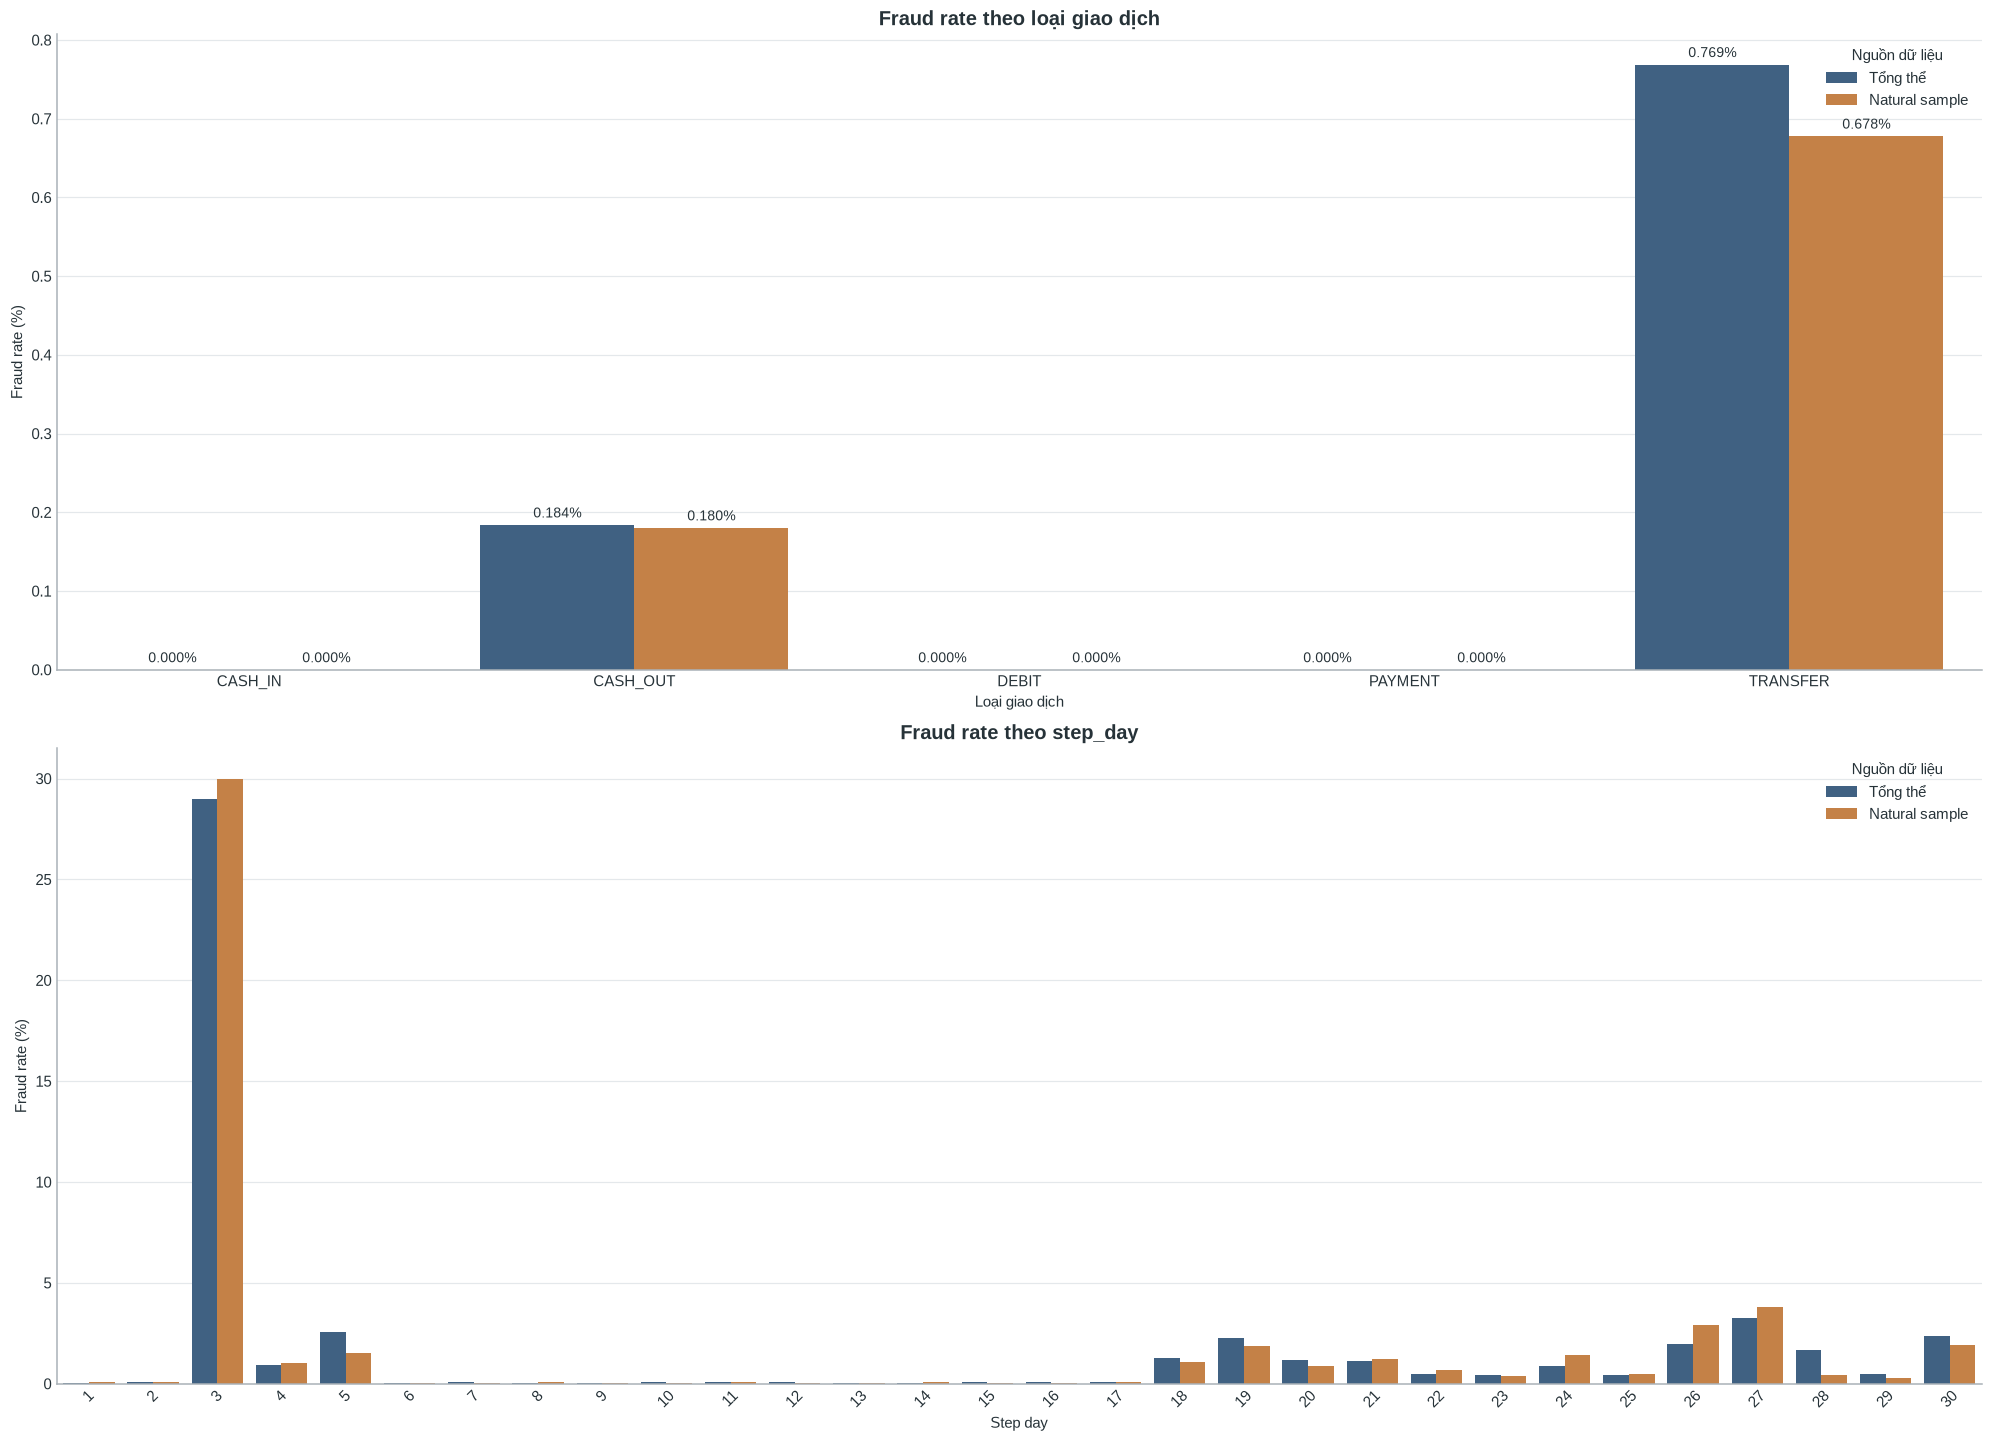

In [29]:
population_by_type = type_summary.reset_index()[
    ["type", "row_count", "fraud_count"]
].assign(dataset="Tổng thể")

sample_by_type = (
    natural_sample.groupby("type")
    .agg(row_count=("isFraud", "size"), fraud_count=("isFraud", "sum"))
    .reset_index()
    .assign(dataset="Natural sample")
)

type_comparison = pd.concat([population_by_type, sample_by_type], ignore_index=True)

type_comparison["fraud_rate_pct"] = (
    type_comparison["fraud_count"] / type_comparison["row_count"] * 100
)

population_by_step = step_summary.reset_index()[
    ["step_day", "row_count", "fraud_count"]
].assign(dataset="Tổng thể")

sample_by_step = (
    natural_sample.groupby("step_day", observed=True)
    .agg(
        row_count=("isFraud", "size"),
        fraud_count=("isFraud", "sum"),
    )
    .reset_index()
    .assign(dataset="Natural sample")
)

step_comparison = pd.concat(
    [population_by_step, sample_by_step],
    ignore_index=True,
)

step_comparison["fraud_rate_pct"] = (
    step_comparison["fraud_count"] / step_comparison["row_count"] * 100
)
step_comparison = step_comparison.loc[step_comparison["step_day"].ne(31)]

type_order = type_summary.index.tolist()
step_order = sorted(step_comparison["step_day"].unique())

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 13), constrained_layout=True)

palette = {
    "Tổng thể": BLUE,
    "Natural sample": ORANGE,
}

sns.barplot(
    data=type_comparison,
    x="type",
    y="fraud_rate_pct",
    hue="dataset",
    order=type_order,
    hue_order=["Tổng thể", "Natural sample"],
    palette=palette,
    errorbar=None,
    ax=axes[0],
)

axes[0].set_title("Fraud rate theo loại giao dịch")
axes[0].set_xlabel("Loại giao dịch")
axes[0].set_ylabel("Fraud rate (%)")
axes[0].set_ylim(bottom=0)
axes[0].legend(title="Nguồn dữ liệu")

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.3f%%",
        padding=3,  # Khoảng cách giữa mép đỉnh và số
        fontsize=9,
    )

sns.barplot(
    data=step_comparison,
    x="step_day",
    y="fraud_rate_pct",
    hue="dataset",
    order=step_order,
    hue_order=["Tổng thể", "Natural sample"],
    palette=palette,
    errorbar=None,
    ax=axes[1],
)

axes[1].set_title("Fraud rate theo step_day")
axes[1].set_xlabel("Step day")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Nguồn dữ liệu")

sns.despine()
plt.show()

Dựa vào đây ta thấy sự chênh lệch giũa mẫu và toàn thể không có sự khác biệt đáng kể.

Ta nhận thấy giá trị 0 chứa khá nhiều trong dữ liệu nên ta có thể giả định, 0 không phải là giá trị lỗi.

Bây giờ ta trực quan phần nhãng


In [30]:
type_summary

,row_count,fraud_count,flagged_fraud_count,amount_sum,fraud_amount_sum,fraud_rate,fraud_per_10k,fraud_amount_rate
type,,,,,,,,
CASH_IN,1399284,0,0,"236,367,391,912.459991",0.000000,0.000000,0.000000,0.000000
CASH_OUT,2237500,4116,0,"394,412,995,224.489990","5,989,202,243.830000",0.001840,18.395531,0.015185
DEBIT,41432,0,0,"227,199,221.280000",0.000000,0.000000,0.000000,0.000000
PAYMENT,2151495,0,0,"28,093,371,138.369999",0.000000,0.000000,0.000000,0.000000
TRANSFER,532909,4097,16,"485,291,987,263.169983","6,067,213,184.010000",0.007688,76.879918,0.012502


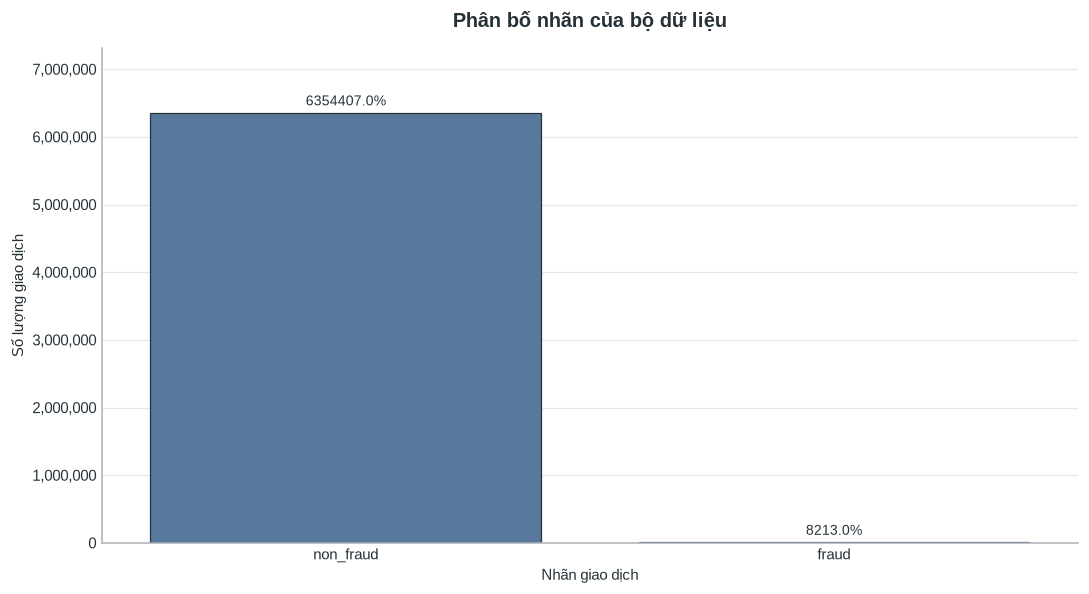

In [31]:
total_count = int(type_summary["row_count"].sum())
fraud_count = int(type_summary["fraud_count"].sum())
non_fraud = total_count - fraud_count

label_balance = pd.DataFrame(
    {"label": ["non_fraud", "fraud"], "count": [non_fraud, fraud_count]}
)

label_balance["per"] = label_balance["count"] / total_count * 100

fig, ax = plt.subplots()

sns.barplot(
    data=label_balance,
    x="label",
    y="count",
    hue="label",
    palette={"non_fraud": "#4C78A8", "fraud": "#E45756"},
    legend=False,
    edgecolor=INK,
    linewidth=0.8,  # Độ dày của nét vẽ
    ax=ax,
)

max_count = label_balance["count"].max()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,  # Khoảng cách giữa mép đỉnh và số
        fontsize=9,
    )

ax.set_title("Phân bố nhãn của bộ dữ liệu", pad=14)
ax.set_xlabel("Nhãn giao dịch")
ax.set_ylabel("Số lượng giao dịch")
ax.set_ylim(0, max_count * 1.15)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

ax.grid(axis="x", visible=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Ta nhận thấy dữ liệu bị lệch rất nặng 

### Phân phối số tiền theo nhãn

Chỉ so sánh `CASH_OUT` và `TRANSFER` vì fraud chỉ xuất hiện ở hai loại giao dịch này. Biểu đồ dùng toàn bộ fraud và non-fraud từ `natural_sample`; `step_day = 31` chỉ bị loại khỏi dữ liệu vẽ theo quyết định ở trên. Dùng `log1p(amount)` để giữ lại giao dịch có `amount = 0` và giảm ảnh hưởng của đuôi phải rất dài.

row_count     amount_p50       amount_p90  \
type     fraud_label                                                 
CASH_OUT Gian lận             3980 438,309.635000 4,448,939.144000   
         Không gian lận      70328 147,781.250000   353,538.318000   
TRANSFER Gian lận             3961 448,265.080000 4,525,901.250000   
         Không gian lận      16702 485,782.525000 1,735,864.599000   

                              amount_p95        amount_p99  
type     fraud_label                                        
CASH_OUT Gian lận       7,782,765.821500 10,000,000.000000  
         Không gian lận   426,694.658000    571,616.979800  
TRANSFER Gian lận       7,937,954.200000 10,000,000.000000  
         Không gian lận 2,638,255.190000 10,000,000.000000

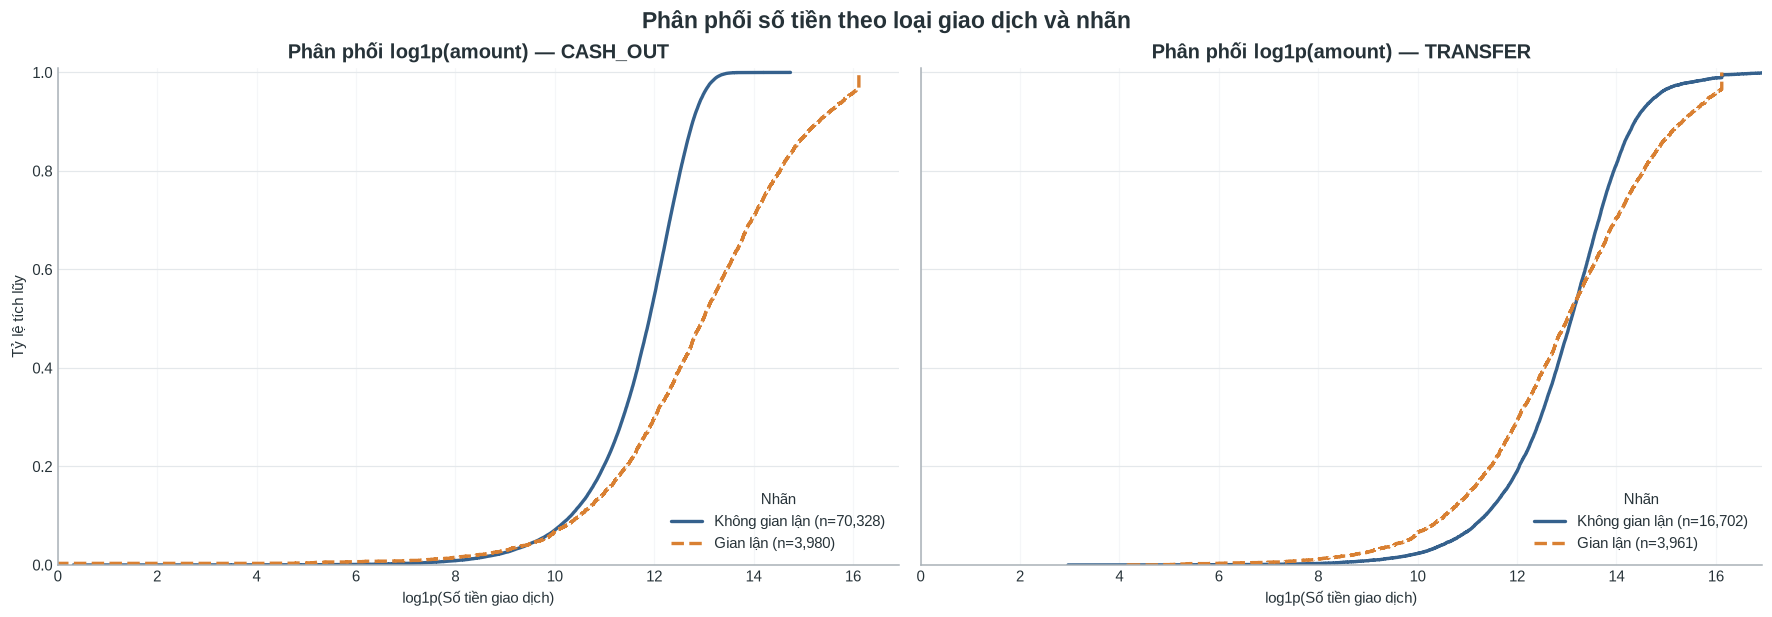

In [32]:
comparison_types = ["CASH_OUT", "TRANSFER"]
fraud_label_order = ["Không gian lận", "Gian lận"]

eda_plot_sample = (
    pd.concat(
        [natural_sample.loc[natural_sample["isFraud"].eq(0)], all_fraud_rows],
        ignore_index=True,
    )
    .loc[lambda row: row["step_day"].ne(31)]
    .copy()
)

eda_plot_sample["fraud_label"] = np.where(
    eda_plot_sample["isFraud"].eq(1),
    "Gian lận",
    "Không gian lận",
)

amount_plot_sample = eda_plot_sample.loc[
    eda_plot_sample["type"].isin(comparison_types), ["type", "amount", "fraud_label"]
]
amount_plot_sample["log1p_amount"] = np.log1p(amount_plot_sample["amount"])
amount_plot_sample
# Vì amount thường hay lệch phải và có chứa số 0 nên ta dùng log1p

amount_group_counts = (
    amount_plot_sample.groupby(
        ["type", "fraud_label"],
        observed=True,
    )
    .size()
    .rename("row_count")
)

amount_quantiles_by_group = (
    amount_plot_sample.groupby(["type", "fraud_label"])["amount"]
    .quantile([0.50, 0.90, 0.95, 0.99])
    .unstack()
    .rename(
        columns={
            0.50: "amount_p50",
            0.90: "amount_p90",
            0.95: "amount_p95",
            0.99: "amount_p99",
        }
    )
)
display(amount_group_counts.to_frame().join(amount_quantiles_by_group))

line_styles = {
    "Không gian lận": {"color": BLUE, "linestyle": "-"},
    "Gian lận": {"color": ORANGE, "linestyle": "--"},
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 5.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, transaction_type in zip(axes, comparison_types):
    type_data = amount_plot_sample.loc[amount_plot_sample["type"] == transaction_type]
    for fraud_label in fraud_label_order:
        label_data = type_data.loc[type_data["fraud_label"].eq(fraud_label)]
        sns.ecdfplot(
            data=label_data,
            x="log1p_amount",
            color=line_styles[fraud_label]["color"],
            linestyle=line_styles[fraud_label]["linestyle"],
            linewidth=2.2,
            label=f"{fraud_label} (n={len(label_data):,})",
            ax=ax,
        )

    ax.set_title(f"Phân phối log1p(amount) — {transaction_type}")
    ax.set_xlabel("log1p(Số tiền giao dịch)")
    ax.set_ylabel("Tỷ lệ tích lũy")
    ax.set_xlim(left=0)
    ax.set_ylim(0, 1.01)
    ax.legend(title="Nhãn", loc="lower right")
    ax.grid(axis="x", alpha=0.35)

fig.suptitle(
    "Phân phối số tiền theo loại giao dịch và nhãn",
    fontsize=15,
    fontweight="bold",
)

sns.despine()
plt.show()

Đối với loại giao dịch rút tiền, số tiền (amount) là một "cờ đỏ" (red flag) cực kỳ đáng tin cậy. Chỉ cần thấy khách hàng rút một số tiền lớn bất thường, hệ thống hoàn toàn có cơ sở để nghi ngờ.

Với giao dịch chuyển khoản,không thể chỉ dùng quy tắc "Tiền lớn là lừa đảo". Mô hình Machine Learning của bạn sẽ cần phải học được đặc điểm ở cả 2 thái cực: những khoản tiền chuyển đi quá nhỏ lẻ và những khoản tiền chuyển đi khổng lồ đột biến.

### Tỷ lệ giá trị bằng 0

Heatmap dưới đây tính tỷ lệ bằng 0 cho từng feature số dư/số tiền theo `type` và nhãn. Ô `N/A` nghĩa là dataset không có quan sát cho tổ hợp đó, không phải tỷ lệ bằng 0%. Tỷ lệ của non-fraud là ước lượng từ `natural_sample`, còn fraud dùng toàn bộ quan sát sau khi loại `step_day = 31` khỏi lớp dữ liệu vẽ.

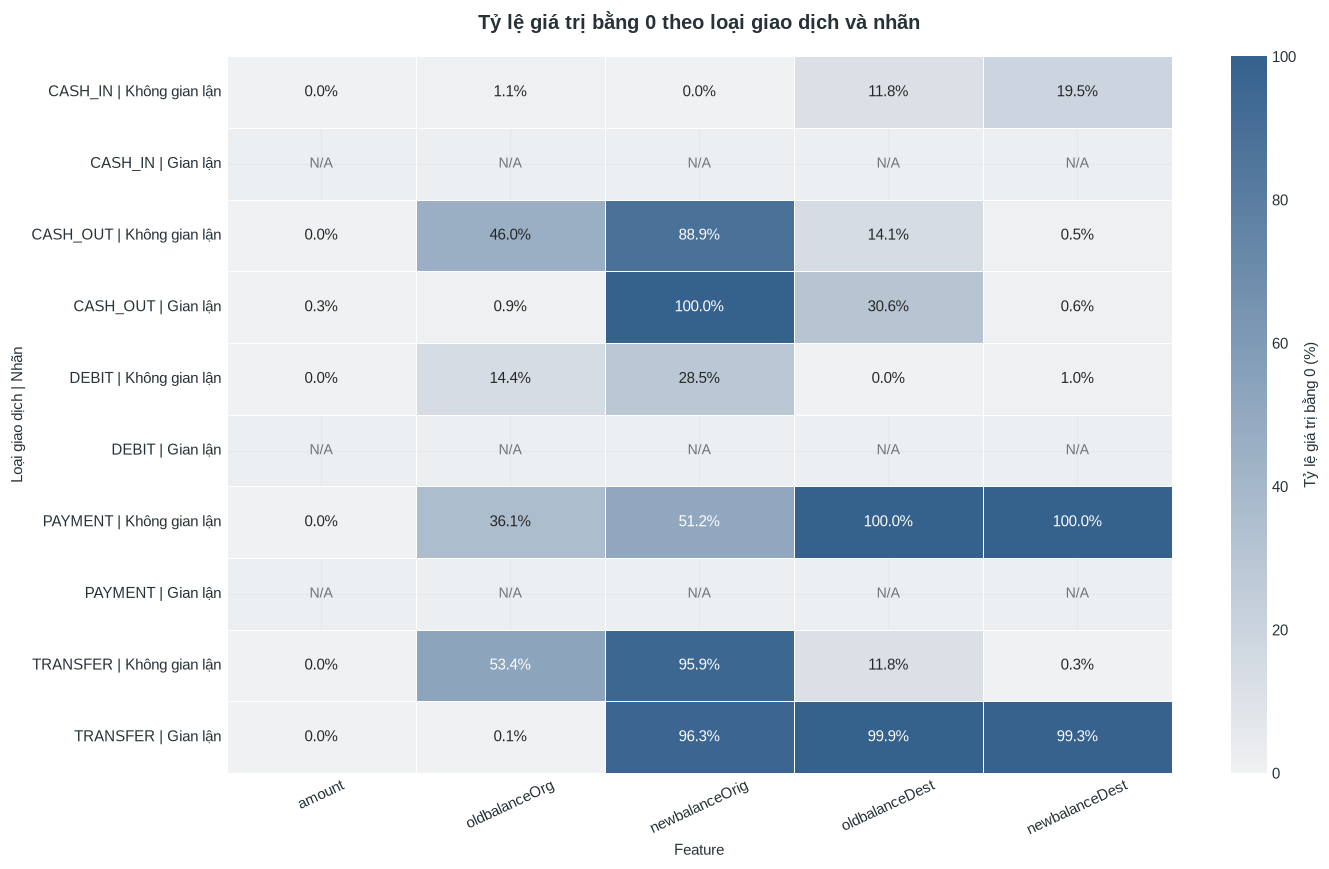

In [33]:
zero_rate_index = pd.MultiIndex.from_product(
    [type_order, fraud_label_order], names=["type", "fraud_label"]
)
zero_rate_pct = (
    eda_plot_sample.groupby(["type", "fraud_label"], observed=True)[VALUE_COLUMNS]
    .agg(lambda column: column.eq(0).mean() * 100)
    .reindex(zero_rate_index)
)

zero_rate_pct.index = [
    f"{transaction_type} | {fraud_label}"
    for transaction_type, fraud_label in zero_rate_pct.index
]
zero_rate_annotations = zero_rate_pct.map(
    lambda value: "" if pd.isna(value) else f"{value:.1f}%"
)

zero_rate_mask = zero_rate_pct.isna()

fig, ax = plt.subplots(figsize=(13, 8))
ax.set_facecolor("#ECEFF1")  # Đặt màu nền cho heatmap

sns.heatmap(
    zero_rate_pct,
    mask=zero_rate_mask,
    annot=zero_rate_annotations,
    fmt="",  # Để format các giá trị trong biểu đồ
    cmap=sns.light_palette(BLUE, as_cmap=True),
    vmin=0,
    vmax=100,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Tỷ lệ giá trị bằng 0 (%)"},  # Thanh tieu đề bên phải
    ax=ax,
)
for row_position, column_position in zip(
    *np.where(zero_rate_mask.to_numpy()), strict=True
):
    ax.text(
        column_position + 0.5,
        row_position + 0.5,
        "N/A",
        ha="center",
        va="center",
        color="#6B747A",
        fontsize=9,
    )

ax.set_title(
    "Tỷ lệ giá trị bằng 0 theo loại giao dịch và nhãn",
    pad=18,
)
ax.set_xlabel("Feature")
ax.set_ylabel("Loại giao dịch | Nhãn")
ax.tick_params(axis="x", rotation=25)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

Ở pattern: PAYMENT, oldbalanceDest và newbalanceDest 100% zero nghĩa là dữ liệu mô phỏng k mô phỏng 2 trường này

Fraud CASH_OUT thường làm số dư origin về 0 trong dữ liệu nhưng non_fraud cũng chiếm 88.9% giá trị 0 nên feature này không đủ mạnh để phân biệt fraud

oldbalanceDest = 99.9%, newbalanceDest = 99.3% zero Đây là pattern rất mạnh và đáng nghi, có thể là artifact của PaySim hoặc leakage từ trạng thái sau giao dịch

Fraud thường xuất hiện khi origin có balance trước giao dịch khác 0

Cần audit kĩ trước khi dùng oldbalanceDest hoặc newbalanceDest làm feature

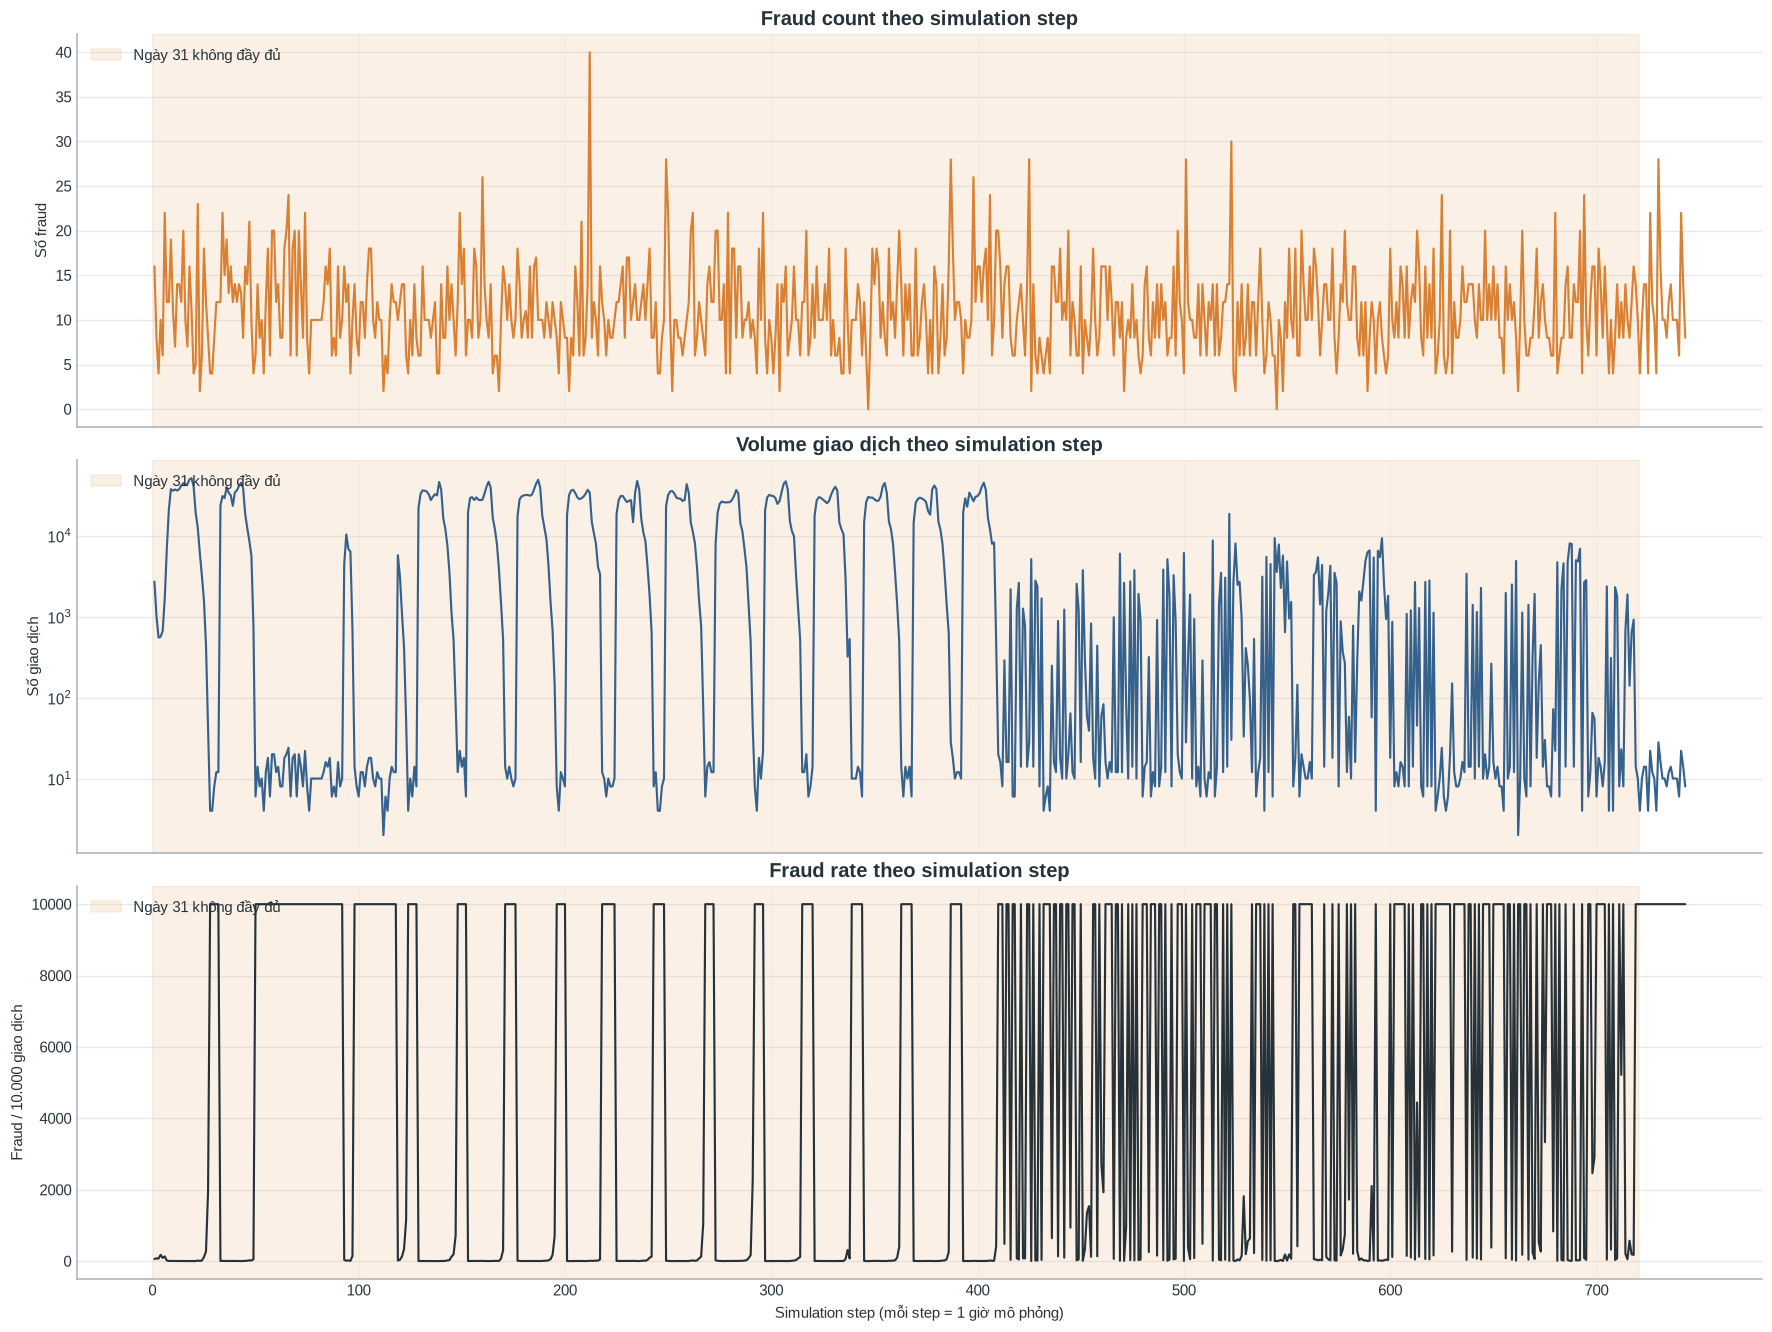

In [34]:
partial_step = hourly_summary.loc[hourly_summary["step_day"].ne(31), "step"]
partial_start = partial_step.min() - 0.5
partial_end = partial_step.max() + 0.5

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 12),
    sharex=True,
    constrained_layout=True,
)

sns.lineplot(
    data=hourly_summary,
    x="step",
    y="fraud_count",
    color=ORANGE,
    linewidth=1.4,
    ax=axes[0],  # Chỉ định vẽ vào khung đầu tiên
)
axes[0].set_title("Fraud count theo simulation step")
axes[0].set_ylabel("Số fraud")
axes[0].set_xlabel("")  # Ẩn nhãn trục X ở biểu đồ trên

# --- Biểu đồ 1: Volume giao dịch ---
sns.lineplot(
    data=hourly_summary,
    x="step",
    y="row_count",
    color=BLUE,
    linewidth=1.4,
    ax=axes[1],  # Chỉ định vẽ vào khung thứ hai
)
axes[1].set_title("Volume giao dịch theo simulation step")
axes[1].set_ylabel("Số giao dịch")
axes[1].set_yscale("log")
axes[1].set_xlabel("")  # Ẩn nhãn trục X ở biểu đồ trên

# --- Biểu đồ 2: Fraud rate ---
sns.lineplot(
    data=hourly_summary,
    x="step",
    y="fraud_per_10k",
    color=INK,
    linewidth=1.4,
    ax=axes[2],  # Chỉ định vẽ vào khung cuối cùng
)
axes[2].set_title("Fraud rate theo simulation step")
axes[2].set_xlabel("Simulation step (mỗi step = 1 giờ mô phỏng)")
axes[2].set_ylabel("Fraud / 10.000 giao dịch")

for ax in axes:
    # Tô màu bôi đen ngày không đầy đủ
    ax.axvspan(
        partial_start,
        partial_end,
        color=LIGHT_ORANGE,
        alpha=0.25,
        label="Ngày 31 không đầy đủ",
    )
    ax.grid(axis="x", alpha=0.35)
    ax.legend(loc="upper left")

# Xóa viền trên và viền phải cho thanh thoát
sns.despine()

# Hiển thị
plt.show()

Heatmap cho fraud_count, fraud_rate, volume

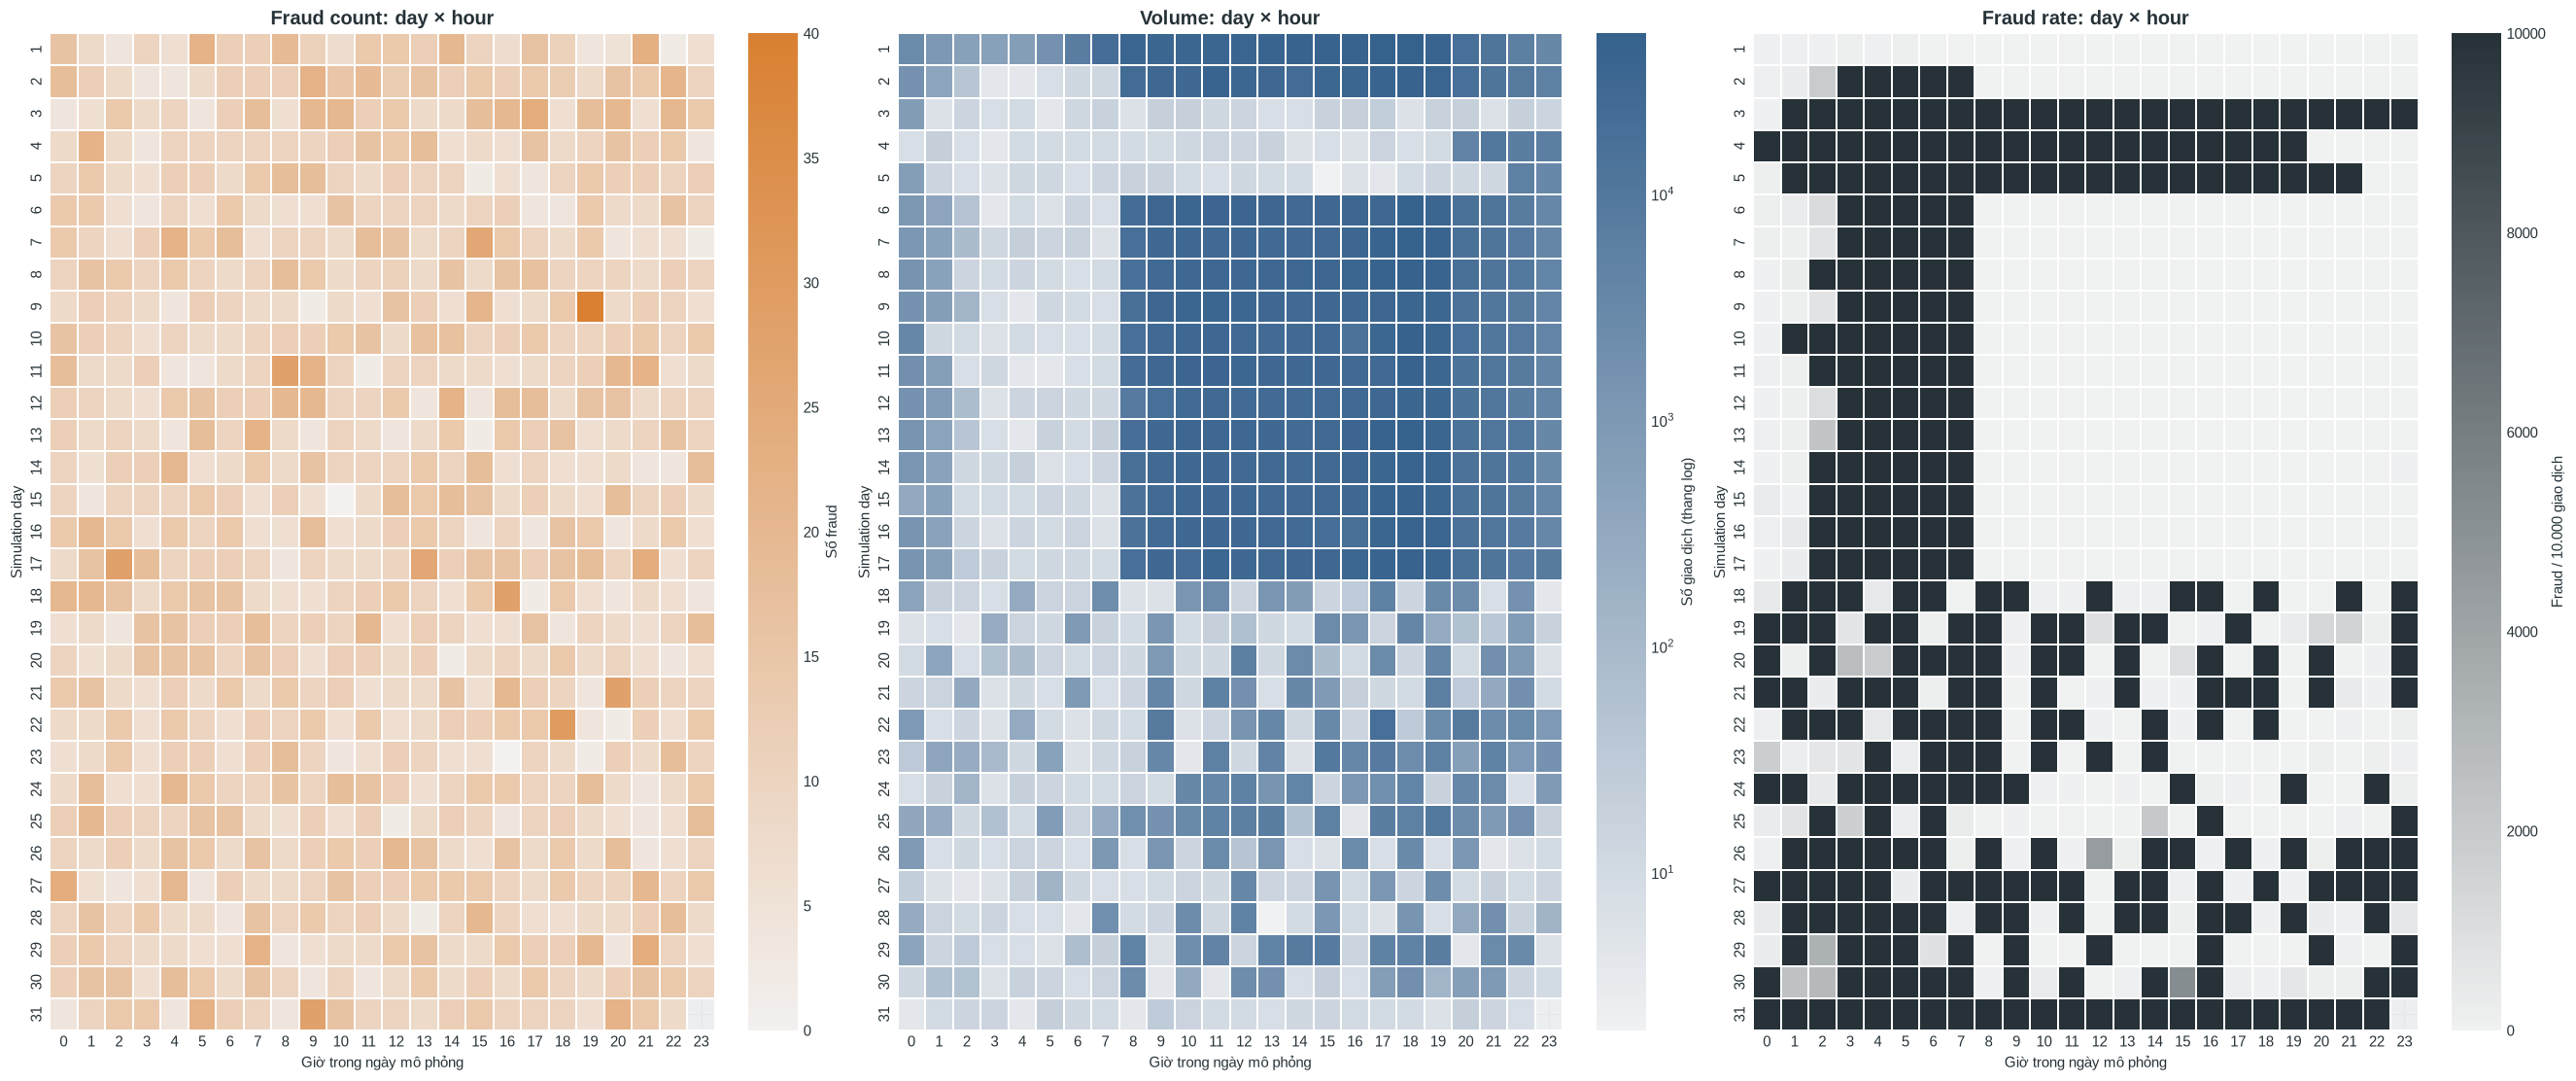

In [35]:
from matplotlib.colors import LogNorm

heatmap_days = pd.Index(
    range(1, int(hourly_summary["step_day"].max() + 1)), name="step_day"
)
heatmap_hours = pd.Index(range(24), name="hour_of_day")


def make_temporal_matrix(value_column: str) -> pd.DataFrame:
    return hourly_summary.pivot(
        index="step_day",
        columns="hour_of_day",
        values=value_column,
    ).reindex(index=heatmap_days, columns=heatmap_hours)


fraud_count_matrix = make_temporal_matrix("fraud_count")
volume_matrix = make_temporal_matrix("row_count")
volume_matrix = volume_matrix.replace(0, np.nan)
fraud_rate_matrix = make_temporal_matrix("fraud_per_10k")

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(24, 10),
    constrained_layout=True,
)

for ax in axes:
    ax.set_facecolor("#ECEFF1")

sns.heatmap(
    fraud_count_matrix,
    cmap=sns.light_palette(ORANGE, as_cmap=True),
    linewidths=0.15,
    linecolor="white",
    cbar_kws={"label": "Số fraud"},
    ax=axes[0],
)
axes[0].set_title("Fraud count: day × hour")

sns.heatmap(
    volume_matrix,
    cmap=sns.light_palette(BLUE, as_cmap=True),
    norm=LogNorm(
        vmin=volume_matrix.stack().min(),
        vmax=volume_matrix.stack().max(),
    ),
    linewidths=0.15,
    linecolor="white",
    cbar_kws={"label": "Số giao dịch (thang log)"},
    ax=axes[1],
)
axes[1].set_title("Volume: day × hour")

sns.heatmap(
    fraud_rate_matrix,
    cmap=sns.light_palette(INK, as_cmap=True),
    vmin=0,
    vmax=fraud_rate_matrix.stack().max(),
    linewidths=0.15,
    linecolor="white",
    cbar_kws={"label": "Fraud / 10.000 giao dịch"},
    ax=axes[2],
)

axes[2].set_title("Fraud rate: day × hour")

for ax in axes:
    ax.set_xlabel("Giờ trong ngày mô phỏng")
    ax.set_ylabel("Simulation day")
    ax.tick_params(axis="x", rotation=0)

plt.show()

Số fraud theo từng ngày/giờ khá ổn định (thường khoảng 200–320 fraud/ngày), nhưng volume giao dịch biến động rất mạnh.

Fraud rate vì vậy tăng vọt tại các ô có volume thấp — đặc biệt vào rạng sáng (giờ 2–5) và các ngày mô phỏng về sau. Đây chủ yếu là hiệu ứng “mẫu số nhỏ”, chưa đủ để khẳng định fraud thực sự tập trung ở các khung giờ đó.

Trong các ngày đầy đủ, volume cao nhất ở khoảng 9–19h; fraud rate thấp hơn rõ rệt, khoảng 5–13 fraud/10.000 giao dịch. Ngược lại, giờ 3–5 có rate rất cao (khoảng 2.100–2.200/10.000) nhưng chỉ có khoảng 1–2 nghìn giao dịch gộp.

In [36]:
BALANCE_COLUMNS = [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]

BALANCE_FEATURE_COLUMNS = [
    "amount",
    *BALANCE_COLUMNS,
]
LABEL_PALETTE = {
    "Không gian lận": BLUE,
    "Gian lận": ORANGE,
}

balance_plot_sample = eda_plot_sample.loc[
    :,
    ["step", "type", "isFraud", "fraud_label", "amount", *BALANCE_COLUMNS],
].copy()

balance_diagnostic_sample = diagnostic_sample.loc[
    diagnostic_sample["step_day"].ne(31),
    ["step", "type", "isFraud", "amount", *BALANCE_COLUMNS],
].copy()


display(
    balance_plot_sample.groupby("fraud_label")
    .size()
    .reindex(fraud_label_order)
    .rename("row_count")
    .to_frame()
)

,row_count
fraud_label,
Không gian lận,199759
Gian lận,7941


fraud_label,Gian lận,Không gian lận
feature,,
oldbalanceOrg,0.48%,33.20%
newbalanceOrig,98.15%,56.80%
oldbalanceDest,65.16%,42.38%
newbalanceDest,49.79%,38.31%


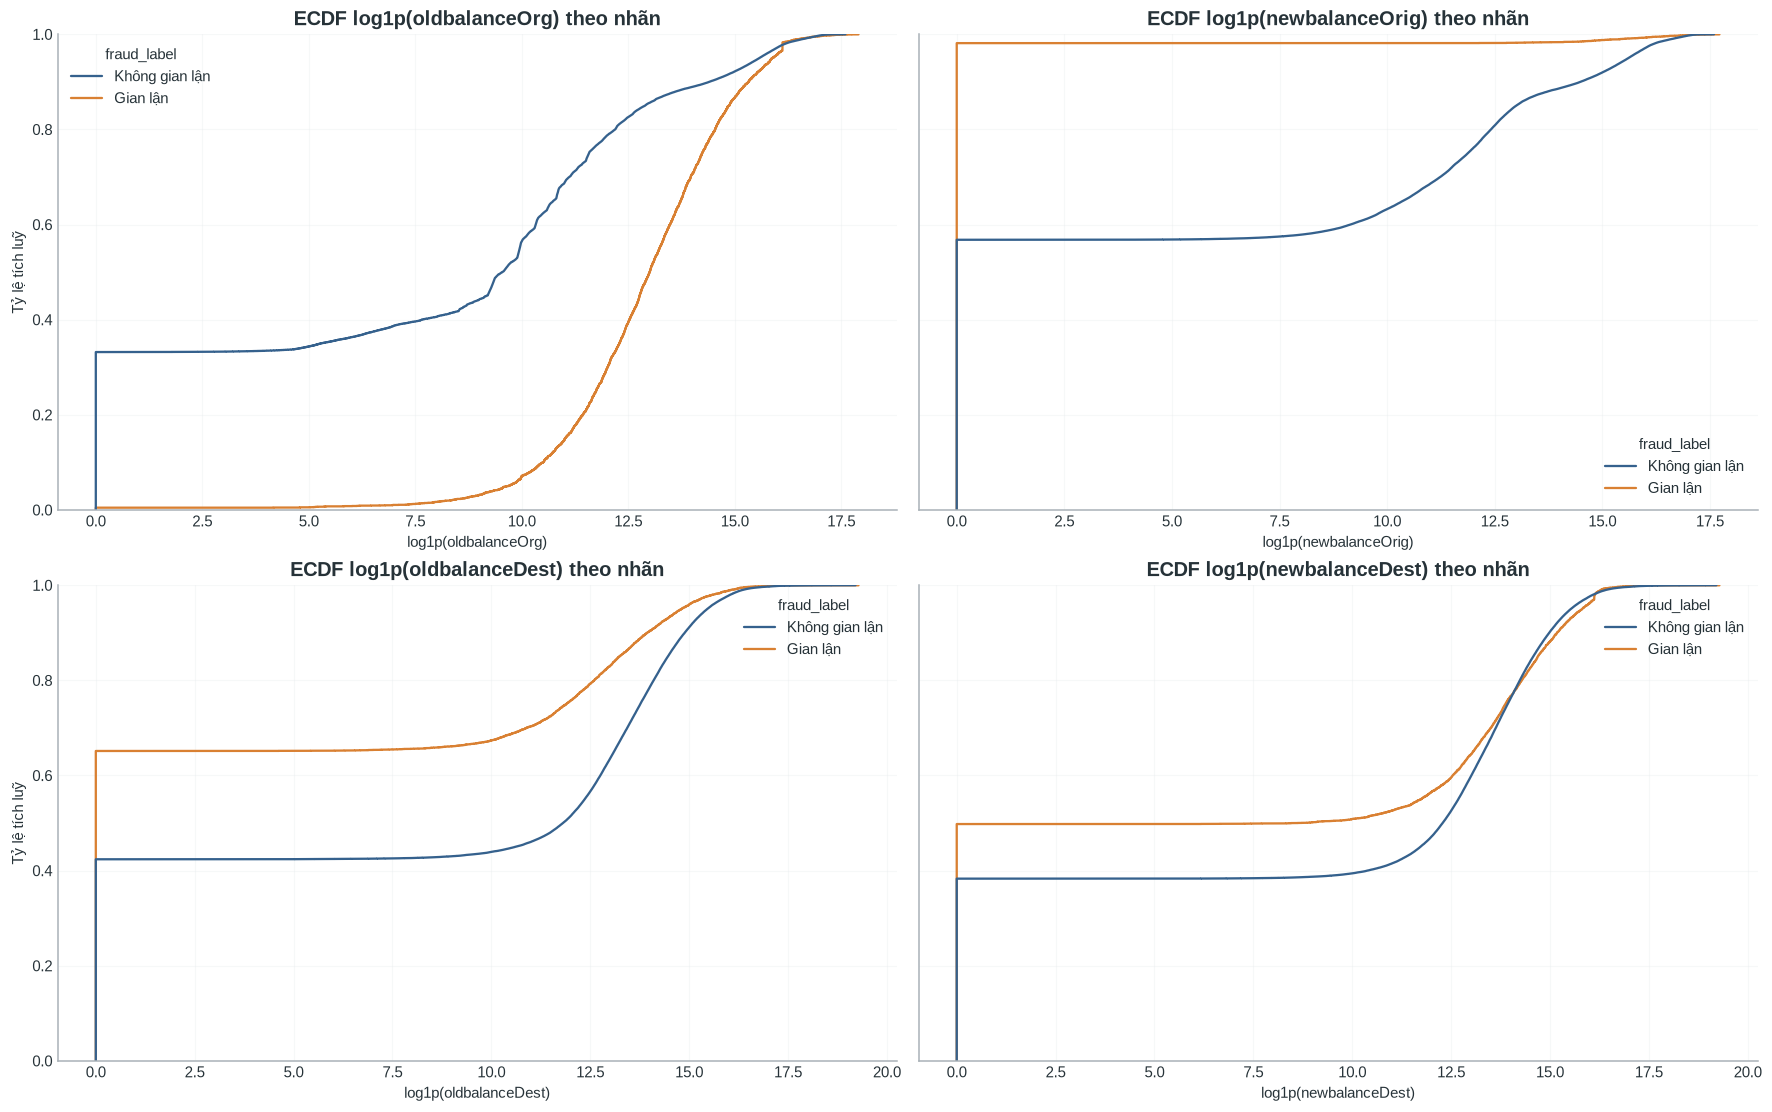

In [37]:
zero_mass_by_label = (
    balance_plot_sample.groupby("fraud_label")[BALANCE_COLUMNS]
    .agg(lambda series: series.eq(0).mean() * 100)
    .T
)
zero_mass_by_label.index.name = "feature"
zero_mass_by_label.columns.name = "fraud_label"

display(zero_mass_by_label.style.format("{:.2f}%"))

balance_long = balance_plot_sample.melt(
    id_vars=["fraud_label"],
    value_vars=BALANCE_COLUMNS,
    var_name="feature",
    value_name="balance",
)
balance_long["log1p_balance"] = np.log1p(balance_long["balance"])

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10),
    sharey=True,
    constrained_layout=True,
)

for feature, ax in zip(BALANCE_COLUMNS, axes.flat, strict=True):
    feature_data = balance_long.loc[balance_long["feature"].eq(feature)]
    sns.ecdfplot(
        data=feature_data,
        x="log1p_balance",
        hue="fraud_label",
        hue_order=fraud_label_order,
        palette=LABEL_PALETTE,
        ax=ax,
    )
    ax.set_title(f"ECDF log1p({feature}) theo nhãn")
    ax.set_xlabel(f"log1p({feature})")
    ax.set_ylabel("Tỷ lệ tích luỹ")
    ax.grid(alpha=0.30)

sns.despine()
plt.show()

Đối với oldbalanceorg ta nên cân nhắc giữ feature này và thêm feature origin_balance_before_is_zero tương tự với feature oldbalanceDest. Vì các feature này chứa số 0 khá nhiều, đây có thể là tính hiệu của việc feature mạnh để training model.

Dựa vào biểu đồ này và tỷ lệ giao dịch bằng 0 theo nhãn và type ta rút ra được một vài kết luận

Đối với oldbalanceOrg,oldbalanceDest,newbalancedest chia theo 0 và !=0 nhưng ở type transfer có thể đưa vào làm đặc trưng, và cũng có thể là đặc trưng rất mạnh.

Còn feature newbalanceOrg ta thấy nó k phải là một feature tốt do k có tính phân biệt mạnh

## EDA bốn engineered balance features

Phần này đánh giá bốn feature trước khi đưa vào mô hình:

- `origin_balance_delta = oldbalanceOrg - newbalanceOrig`
- `destination_balance_delta = newbalanceDest - oldbalanceDest`
- `origin_amount_residual = abs(origin_balance_delta - amount)`
- `destination_amount_residual = abs(destination_balance_delta - amount)`

**Phạm vi ra quyết định:** chỉ dùng `step_day <= 21` (xấp xỉ cửa sổ train trong cấu hình dự án), đồng thời chỉ xét `CASH_OUT` và `TRANSFER` vì fraud chỉ xuất hiện ở hai loại giao dịch này. Không dùng ngày validation/test để chọn feature. Mẫu gồm toàn bộ fraud và natural sample của non-fraud; vì vậy các tỷ lệ fraud trong phần này không đại diện cho tỷ lệ fraud ngoài thực tế.

Bốn feature dùng số dư sau giao dịch. Chúng chỉ hợp lệ nếu mô hình chạy tại prediction point `post_ledger_update`; nếu mục tiêu là chặn giao dịch trước khi cập nhật sổ cái thì đây là leakage.

In [45]:
ENGINEERED_BALANCE_FEATURES = [
    "origin_balance_delta",
    "destination_balance_delta",
    "origin_amount_residual",
    "destination_amount_residual",
]
FEATURE_EDA_TYPES = ["CASH_OUT", "TRANSFER"]


def add_balance_features(frame: pd.DataFrame) -> pd.DataFrame:
    required_columns = {
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
    }
    missing_columns = required_columns.difference(frame.columns)
    if missing_columns:
        raise KeyError(f"Thiếu cột đầu vào: {sorted(missing_columns)}")

    result = frame.copy()
    result["origin_balance_delta"] = (
        result["oldbalanceOrg"] - result["newbalanceOrig"]
    )
    result["destination_balance_delta"] = (
        result["newbalanceDest"] - result["oldbalanceDest"]
    )
    result["origin_amount_residual"] = np.abs(
        result["origin_balance_delta"] - result["amount"]
    )
    result["destination_amount_residual"] = np.abs(
        result["destination_balance_delta"] - result["amount"]
    )
    return result


feature_eda_columns = [
    "step",
    "step_day",
    "type",
    "isFraud",
    "fraud_label",
    "amount",
    *BALANCE_COLUMNS,
]
feature_eda_base = eda_plot_sample.loc[
    eda_plot_sample["type"].isin(FEATURE_EDA_TYPES),
    feature_eda_columns,
].copy()
engineered_balance_sample = add_balance_features(feature_eda_base)

feature_values = engineered_balance_sample[ENGINEERED_BALANCE_FEATURES]
assert feature_values.notna().all().all(), "Engineered features chứa missing value."
assert np.isfinite(feature_values.to_numpy()).all(), "Engineered features chứa giá trị vô hạn."
assert engineered_balance_sample[
    ["origin_amount_residual", "destination_amount_residual"]
].ge(0).all().all(), "Residual phải không âm."

feature_eda_scope = (
    engineered_balance_sample.groupby(["type", "fraud_label"], observed=True)
    .agg(rows=("isFraud", "size"))
    .reset_index()
)
display(feature_eda_scope)

,type,fraud_label,rows
0,CASH_OUT,Gian lận,3980
1,CASH_OUT,Không gian lận,70328
2,TRANSFER,Gian lận,3961
3,TRANSFER,Không gian lận,16702


### 1. Chất lượng dữ liệu và hình dạng phân phối

Bảng dưới kiểm tra missing/infinite, tỷ lệ bằng 0, tỷ lệ âm và các phân vị. Với delta, giá trị âm là tín hiệu cần quan sát chứ không tự động là lỗi. Với residual, giá trị gần 0 nghĩa là biến động số dư khớp với `amount` trong sai số một cent.

In [39]:
feature_distribution_long = engineered_balance_sample.melt(
    id_vars=["type", "fraud_label"],
    value_vars=ENGINEERED_BALANCE_FEATURES,
    var_name="feature",
    value_name="value",
)

engineered_balance_feature_summary = (
    feature_distribution_long.groupby(
        ["type", "fraud_label", "feature"], observed=True
    )["value"]
    .agg(
        rows="size",
        missing=lambda values: values.isna().sum(),
        zero_rate=lambda values: values.eq(0).mean(),
        negative_rate=lambda values: values.lt(0).mean(),
        mean="mean",
        p50="median",
        p90=lambda values: values.quantile(0.90),
        p95=lambda values: values.quantile(0.95),
        p99=lambda values: values.quantile(0.99),
        maximum="max",
    )
    .reset_index()
)

engineered_balance_feature_summary.to_csv(
    REPORT_DIR / "engineered_balance_feature_train_summary.csv", index=False
)
display(
    engineered_balance_feature_summary.style.format(
        {
            "zero_rate": "{:.2%}",
            "negative_rate": "{:.2%}",
            "mean": "{:,.2f}",
            "p50": "{:,.2f}",
            "p90": "{:,.2f}",
            "p95": "{:,.2f}",
            "p99": "{:,.2f}",
            "maximum": "{:,.2f}",
        }
    )
)

,type,fraud_label,feature,rows,missing,zero_rate,negative_rate,mean,p50,p90,p95,p99,maximum
0,CASH_OUT,Gian lận,destination_amount_residual,3980,0,52.76%,0.00%,"14,442.24",0.00,0.01,0.01,"248,767.33","8,875,516.29"
1,CASH_OUT,Gian lận,destination_balance_delta,3980,0,0.38%,0.65%,"1,461,270.01","443,202.49","4,457,228.28","7,815,734.59","10,000,000.00","14,915,111.47"
2,CASH_OUT,Gian lận,origin_amount_residual,3980,0,99.37%,0.00%,"1,350.76",0.00,0.00,0.00,0.00,"577,418.98"
3,CASH_OUT,Gian lận,origin_balance_delta,3980,0,0.85%,0.00%,"1,450,069.98","436,831.99","4,448,939.14","7,782,765.82","10,000,000.00","10,000,000.00"
4,CASH_OUT,Không gian lận,destination_amount_residual,70328,0,26.82%,0.00%,"29,499.71",0.00,0.01,"167,107.86","556,977.16","26,804,108.60"
5,CASH_OUT,Không gian lận,destination_balance_delta,70328,0,0.06%,1.78%,"191,004.21","150,586.28","381,868.74","476,841.54","807,162.52","27,421,369.18"
6,CASH_OUT,Không gian lận,origin_amount_residual,70328,0,5.91%,0.00%,"148,926.31","120,623.42","330,996.08","404,025.79","551,444.76","2,523,516.26"
7,CASH_OUT,Không gian lận,origin_balance_delta,70328,0,45.97%,0.00%,"25,587.11",494.00,"80,725.25","129,282.75","257,757.12","664,457.76"
8,TRANSFER,Gian lận,destination_amount_residual,3961,0,0.00%,0.00%,"1,471,043.82","447,474.67","4,525,901.25","7,937,954.20","10,000,000.00","10,000,000.00"
9,TRANSFER,Gian lận,destination_balance_delta,3961,0,99.27%,0.03%,"3,007.87",0.00,0.00,0.00,0.00,"1,933,920.80"


In [40]:
MONETARY_TOLERANCE = 0.01

engineered_balance_consistency_summary = (
    engineered_balance_sample.assign(
        origin_delta_negative=lambda frame: frame["origin_balance_delta"].lt(0),
        destination_delta_negative=lambda frame: frame[
            "destination_balance_delta"
        ].lt(0),
        origin_amount_exact_match=lambda frame: frame[
            "origin_amount_residual"
        ].le(MONETARY_TOLERANCE),
        destination_amount_exact_match=lambda frame: frame[
            "destination_amount_residual"
        ].le(MONETARY_TOLERANCE),
    )
    .groupby(["type", "fraud_label"], observed=True)
    .agg(
        rows=("isFraud", "size"),
        origin_delta_negative_rate=("origin_delta_negative", "mean"),
        destination_delta_negative_rate=("destination_delta_negative", "mean"),
        origin_exact_match_rate=("origin_amount_exact_match", "mean"),
        destination_exact_match_rate=("destination_amount_exact_match", "mean"),
        origin_residual_p50=("origin_amount_residual", "median"),
        destination_residual_p50=("destination_amount_residual", "median"),
    )
    .reset_index()
)

engineered_balance_consistency_summary.to_csv(
    REPORT_DIR / "engineered_balance_consistency_train_summary.csv", index=False
)
display(
    engineered_balance_consistency_summary.style.format(
        {
            "origin_delta_negative_rate": "{:.2%}",
            "destination_delta_negative_rate": "{:.2%}",
            "origin_exact_match_rate": "{:.2%}",
            "destination_exact_match_rate": "{:.2%}",
            "origin_residual_p50": "{:,.2f}",
            "destination_residual_p50": "{:,.2f}",
        }
    )
)

,type,fraud_label,rows,origin_delta_negative_rate,destination_delta_negative_rate,origin_exact_match_rate,destination_exact_match_rate,origin_residual_p50,destination_residual_p50
0,CASH_OUT,Gian lận,3980,0.00%,0.65%,99.40%,87.19%,0.00,0.00
1,CASH_OUT,Không gian lận,70328,0.00%,1.78%,10.69%,80.08%,"120,623.42",0.00
2,TRANSFER,Gian lận,3961,0.00%,0.03%,99.55%,0.05%,0.00,"447,474.67"
3,TRANSFER,Không gian lận,16702,0.00%,0.90%,3.80%,78.09%,"454,253.08",0.00


### 2. So sánh phân phối fraud và non-fraud

ECDF được dùng thay cho histogram vì các feature lệch phải mạnh và có nhiều điểm đúng bằng 0. Trục x dùng signed `log1p`: delta vẫn giữ dấu, residual vẫn không âm. Khoảng cách theo chiều dọc giữa hai đường thể hiện mức khác biệt phân phối, nhưng chưa phải hiệu năng của mô hình.

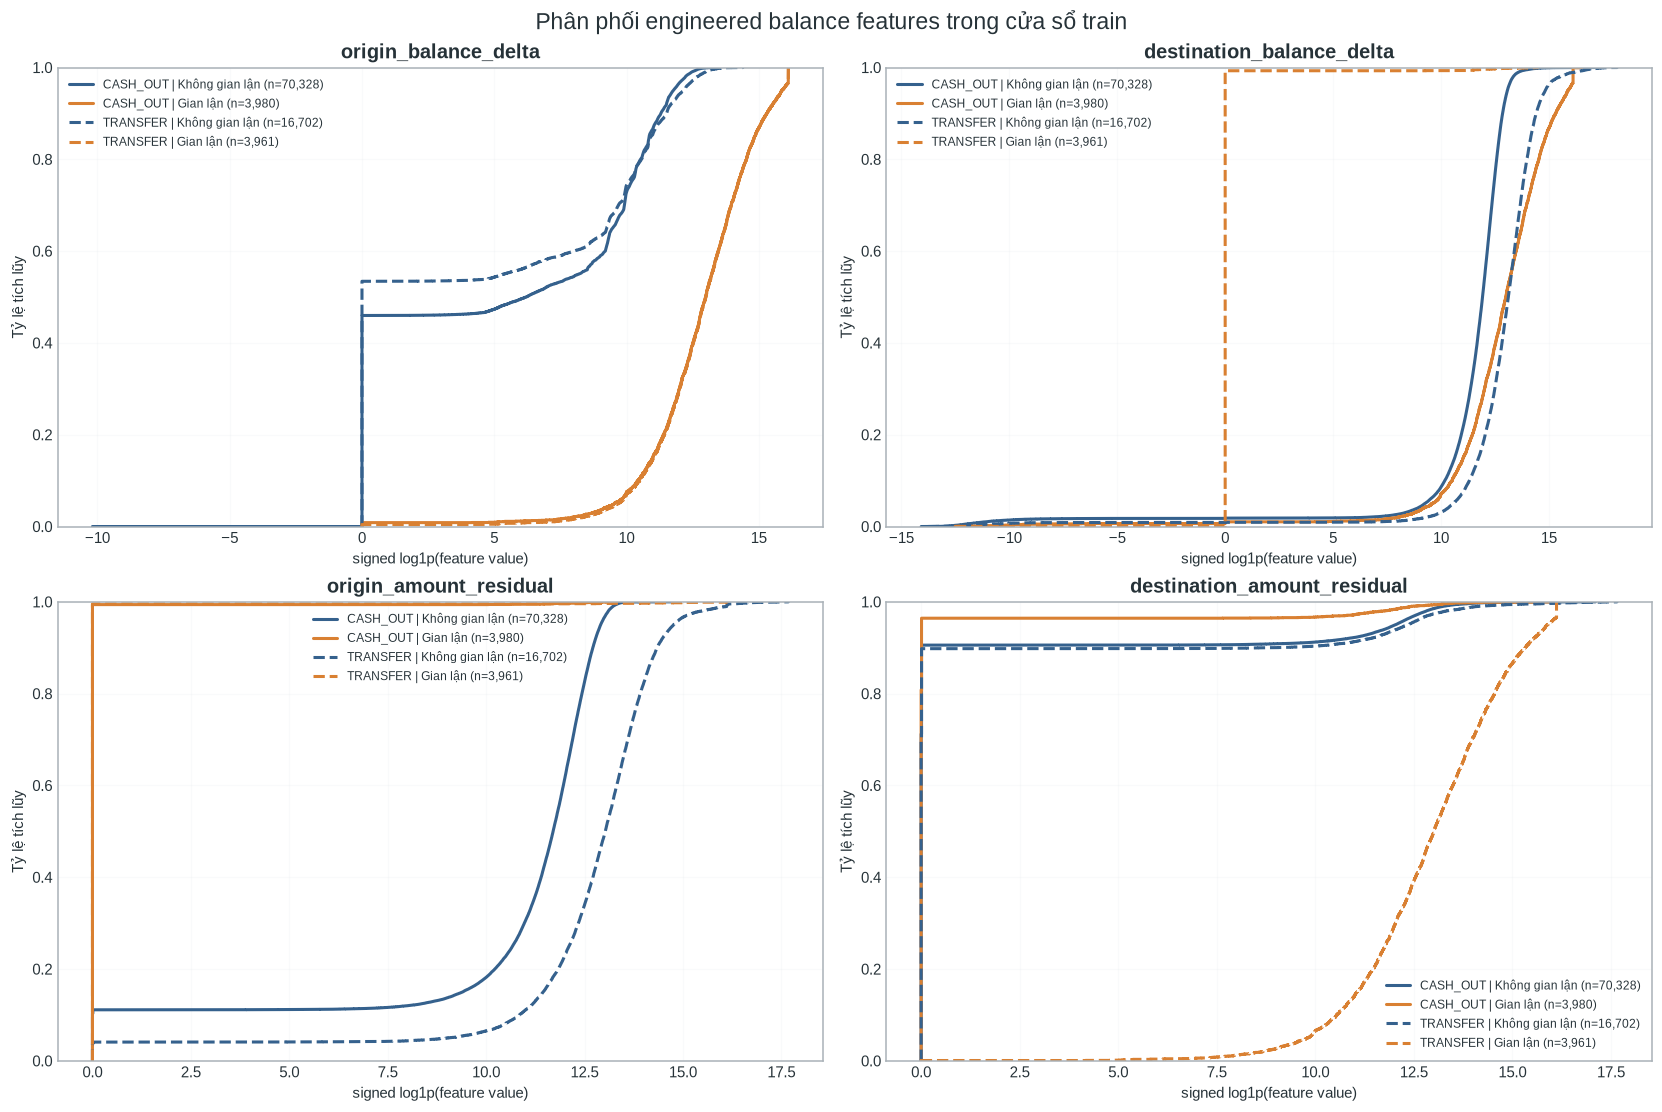

In [41]:
def signed_log1p(values: pd.Series) -> pd.Series:
    return np.sign(values) * np.log1p(np.abs(values))


label_colors = {"Không gian lận": BLUE, "Gian lận": ORANGE}
type_line_styles = {"CASH_OUT": "-", "TRANSFER": "--"}

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
for axis, feature in zip(axes.flat, ENGINEERED_BALANCE_FEATURES):
    for transaction_type in FEATURE_EDA_TYPES:
        for fraud_label in fraud_label_order:
            mask = (
                engineered_balance_sample["type"].eq(transaction_type)
                & engineered_balance_sample["fraud_label"].eq(fraud_label)
            )
            values = signed_log1p(engineered_balance_sample.loc[mask, feature])
            sns.ecdfplot(
                x=values,
                ax=axis,
                color=label_colors[fraud_label],
                linestyle=type_line_styles[transaction_type],
                linewidth=2,
                label=f"{transaction_type} | {fraud_label} (n={mask.sum():,})",
            )
    axis.set_title(feature)
    axis.set_xlabel("signed log1p(feature value)")
    axis.set_ylabel("Tỷ lệ tích lũy")
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)

fig.suptitle(
    "Phân phối engineered balance features trong cửa sổ train",
    fontsize=15,
)
fig.savefig(REPORT_DIR / "engineered_balance_feature_ecdf.png", dpi=160)
plt.show()

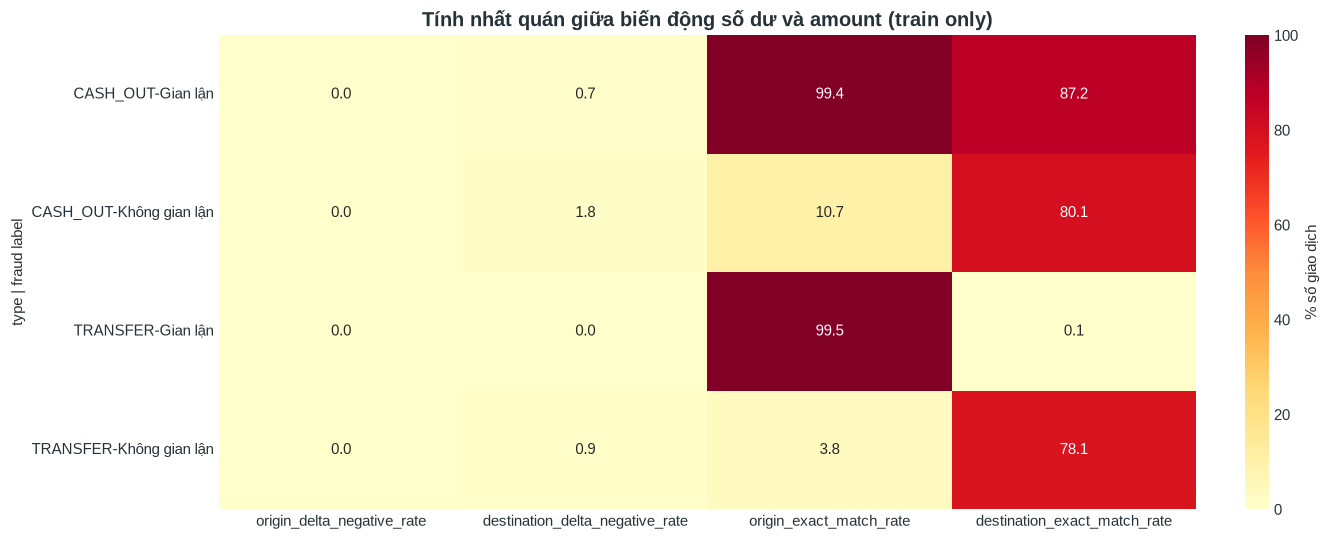

In [42]:
consistency_rate_columns = [
    "origin_delta_negative_rate",
    "destination_delta_negative_rate",
    "origin_exact_match_rate",
    "destination_exact_match_rate",
]
consistency_heatmap = (
    engineered_balance_consistency_summary.set_index(["type", "fraud_label"])[
        consistency_rate_columns
    ]
    * 100
)

fig, axis = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
sns.heatmap(
    consistency_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% số giao dịch"},
    ax=axis,
)
axis.set_title("Tính nhất quán giữa biến động số dư và amount (train only)")
axis.set_xlabel("")
axis.set_ylabel("type | fraud label")
fig.savefig(REPORT_DIR / "engineered_balance_consistency_heatmap.png", dpi=160)
plt.show()

### 3. Kiểm tra dư thừa giữa các feature

Spearman correlation được tính riêng theo transaction type. Tương quan cao không đồng nghĩa phải xóa feature ngay, nhưng cảnh báo rằng `amount`, delta và residual có thể đang mã hóa cùng một quy tắc; với logistic regression cần dùng preprocessing/regularization và kiểm tra ablation.


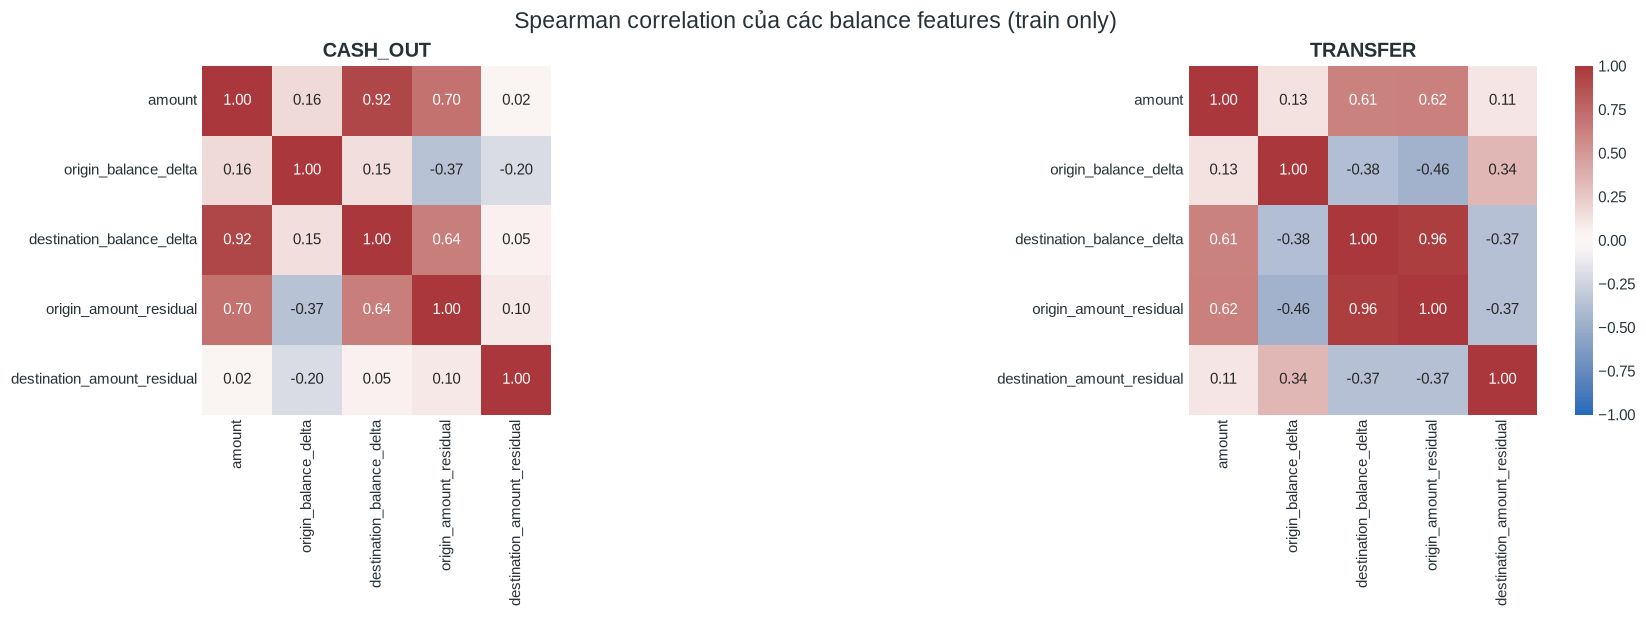

In [44]:
correlation_columns = ["amount", *ENGINEERED_BALANCE_FEATURES]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
for axis, transaction_type in zip(axes, FEATURE_EDA_TYPES):
    correlation_matrix = engineered_balance_sample.loc[
        engineered_balance_sample["type"].eq(transaction_type), correlation_columns
    ].corr(method="spearman")
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        vmin=-1,
        vmax=1,
        square=True,
        cbar=axis is axes[-1],
        ax=axis,
    )
    axis.set_title(transaction_type)

fig.suptitle("Spearman correlation của các balance features (train only)", fontsize=15)
fig.savefig(REPORT_DIR / "engineered_balance_spearman_correlation.png", dpi=160)
plt.show()